<a href="https://colab.research.google.com/github/annukumariii/salary-prediction-using-ml/blob/main/simple_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Part 1: Import Libraries and Setup**


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

**Part 2: Load Dataset**

In [9]:
# Dataset: Salary Prediction Using Simple Linear Regression
# Source: https://www.kaggle.com/datasets/deepita123/salary-prediction-using-simple-linear-regression
url = "https://raw.githubusercontent.com/alicevillar/salary_prediction/main/Salary_Data.csv"
df = pd.read_csv(url)
print("Dataset loaded successfully from Kaggle!")

Dataset loaded successfully from Kaggle!


**Part 3: View First Few Rows**

In [10]:
# Display the first 5 rows to understand the structure
print(df.head())

   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0


**Part 4: Basic Information About the Dataset**

In [11]:
# Get data types and non-null counts
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes
None


**Part 5: Statistical Summary**

In [12]:
# View descriptive statistics for numerical columns
print(df.describe())

       YearsExperience         Salary
count        30.000000      30.000000
mean          5.313333   76003.000000
std           2.837888   27414.429785
min           1.100000   37731.000000
25%           3.200000   56720.750000
50%           4.700000   65237.000000
75%           7.700000  100544.750000
max          10.500000  122391.000000


**Part 6: Check for Missing**

In [13]:
# Count missing values in each column
print(df.isnull().sum())

YearsExperience    0
Salary             0
dtype: int64


**Part 7: Visualize Data Distribution (Histogram)**

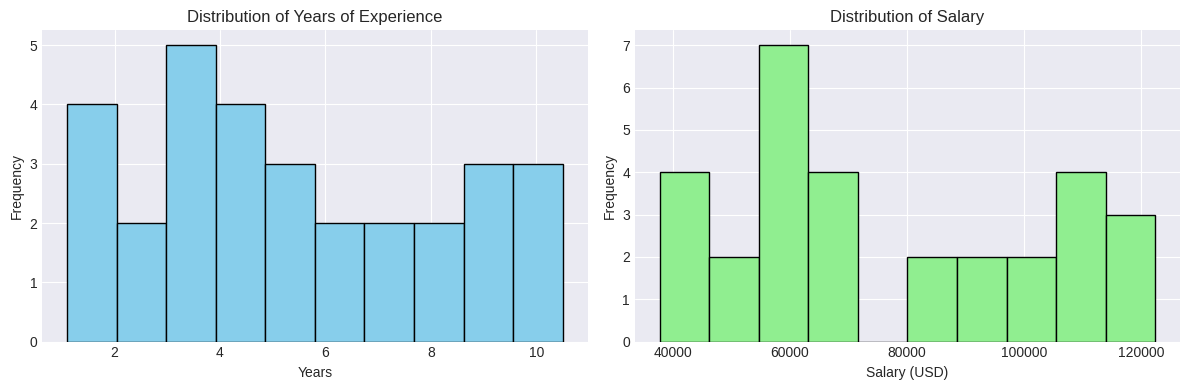

In [14]:
# Plot histograms for both features
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(df['YearsExperience'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution of Years of Experience')
plt.xlabel('Years')
plt.ylabel('Frequency')

plt.subplot(1,2,2)
plt.hist(df['Salary'], bins=10, color='lightgreen', edgecolor='black')
plt.title('Distribution of Salary')
plt.xlabel('Salary (USD)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

**Part 8: Visualize Relationship (Scatter Plot)**

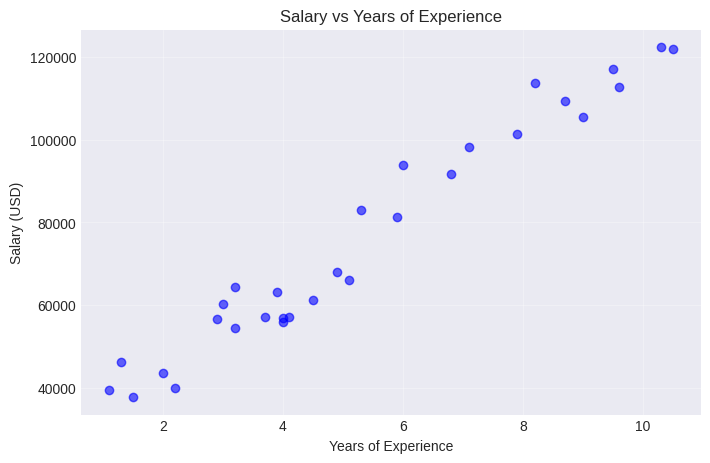

In [15]:
# Create a scatter plot to see the relationship
plt.figure(figsize=(8,5))
plt.scatter(df['YearsExperience'], df['Salary'], alpha=0.6, color='blue')
plt.title('Salary vs Years of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary (USD)')
plt.grid(True, alpha=0.3)
plt.show()

**Part 9: Define Features (X) and Target (y)**

In [16]:
# X is the independent variable (2D array)
X = df[['YearsExperience']]

# y is the dependent variable (1D array)
y = df['Salary']

**Part 10: Split Data into Training and Testing Sets**

In [17]:
# Split 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 24 samples
Testing set size: 6 samples


**Part 11: Create the Linear Regression Model**

In [18]:
# Initialize the model
model = LinearRegression()

**Part 12: Train the Model**

In [19]:
# Fit the model to the training data
model.fit(X_train, y_train)
print("Model training completed!")

Model training completed!


**Part 13: View the Model Equation**

In [20]:
# Extract the intercept (β0) and coefficient (β1)
intercept = model.intercept_
coefficient = model.coef_[0]

print(f"Equation: Salary = {intercept:.2f} + {coefficient:.2f} * YearsExperience")

Equation: Salary = 25321.58 + 9423.82 * YearsExperience


**Part 14: Make Predictions on the Test Set**

In [21]:
# Use the trained model to predict on the test data
y_pred = model.predict(X_test)
print("Predictions made on test set.")

Predictions made on test set.


**Part 15: Evaluate Model Performance (MSE, RMSE, R²)**

In [22]:
# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error
rmse = np.sqrt(mse)

# R-squared (coefficient of determination)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.4f}")

Mean Squared Error (MSE): 49830096.86
Root Mean Squared Error (RMSE): 7059.04
R-squared (R²): 0.9024


**Part 16: Plot the Regression Line with Test Data**

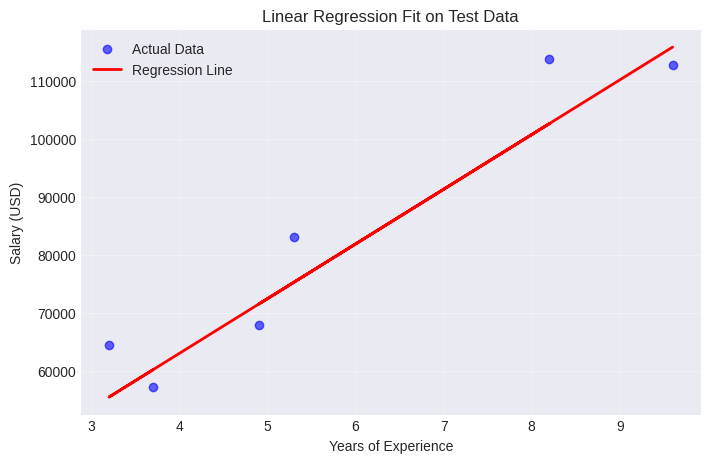

In [23]:
# Plot the test data points and the regression line
plt.figure(figsize=(8,5))
plt.scatter(X_test, y_test, color='blue', alpha=0.6, label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary (USD)')
plt.title('Linear Regression Fit on Test Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Part 17: Plot Residuals (Errors) vs Predicted Values**

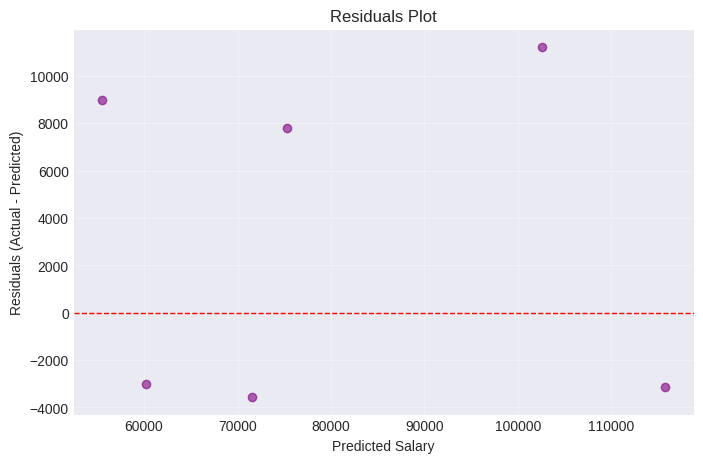

In [24]:
# Calculate residuals
residuals = y_test - y_pred

# Plot residuals
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.6, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Predicted Salary')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residuals Plot')
plt.grid(True, alpha=0.3)
plt.show()

**Part 18: Predict for a New Value (e.g., 5 years of experience)**

In [25]:
# Input a new value (must be 2D)
new_experience = [[5.0]]
predicted_salary = model.predict(new_experience)

print(f"Predicted salary for 5 years of experience: ${predicted_salary[0]:,.2f}")

Predicted salary for 5 years of experience: $72,440.66


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


**Part 19: Save the Model for Future Use**

In [26]:
# Save the trained model to a file using joblib
import joblib
joblib.dump(model, 'salary_model.pkl')
print("Model saved as 'salary_model.pkl'")

Model saved as 'salary_model.pkl'


**Part 20: Load the Saved Model (Example)**

In [27]:
# Example of how to load and use the model later
loaded_model = joblib.load('salary_model.pkl')
pred = loaded_model.predict([[8.0]])
print(f"Predicted salary for 8 years experience (using saved model): ${pred[0]:,.2f}")

Predicted salary for 8 years experience (using saved model): $100,712.11


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
